In [1]:
# Cell 1: Install All Required Libraries

# The '!' character lets you run shell commands directly in Colab.
# We use '-q' for a quiet installation to reduce output clutter.
print("⏳ Installing core libraries...")
!pip install yfinance pandas numpy networkx -q

print("⏳ Installing PyTorch (CPU version)...")
# Using the standard Colab command for PyTorch installation
!pip install torch torchvision torchaudio -q

print("⏳ Installing PyTorch Geometric...")
!pip install torch_geometric -q

print("✅ All libraries installed successfully!")

⏳ Installing core libraries...
⏳ Installing PyTorch (CPU version)...
⏳ Installing PyTorch Geometric...
✅ All libraries installed successfully!


In [2]:
# Cell 2: Setup Project Path (Local Execution)

import sys
import os

# Get the absolute path to the project root (assuming notebook is in 'notebooks/')
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# Verify 'src' directory exists
src_path = os.path.join(project_root, 'src')

if os.path.exists(src_path) and os.path.isdir(src_path):
    print(f"✅ Project root added to path: {project_root}")
    print("✅ 'src' directory detection successful.")
    print("\nYou can now import modules from 'src' in the following cells.")
else:
    print(f"❌ Error: 'src' directory not found at {src_path}")
    print("Please ensure this notebook is inside the 'notebooks' folder of your project structure.")

✅ Project root added to path: /Users/aryan/datathon/resili-net
✅ 'src' directory detection successful.

You can now import modules from 'src' in the following cells.


In [3]:
!rm -rf data/historical_market_data_INDIA.pkl

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Cell 3: Import Modules and Run the Data Pipeline

import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# --- Ensure Project Root is in Path (Redundant safety check) ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import necessary modules from src
try:
    from src.data_loader import fetch_and_cache_market_data, engineer_features, get_market_data_for_timestep
    from src.graph_builder import build_graph_for_timestep
    print("✅ Successfully imported modules from src.")
except ImportError as e:
    print(f"❌ ImportError: {e}")
    print("Ensure you are running this notebook from the 'notebooks' directory and 'src' exists in the project root.")

# Define start and end dates
start_date = '2005-08-08'
end_date = '2022-08-08'

print("\n--- Starting Data Pipeline ---")

# 1. Fetch and cache raw data.
# The data loader config should point to the correct data directory.
# If needed, we ensure the data directory exists in the project root, not just local to the notebook.
data_dir = os.path.join(project_root, 'data')
os.makedirs(data_dir, exist_ok=True)
print(f"Using data directory: {data_dir}")

raw_data = fetch_and_cache_market_data(start_date, end_date)

# 2. Engineer features
processed_data = engineer_features(raw_data)

# 3. Re-index for easy time-based slicing (important for the graph builder)
# Note: 'Date' and 'Ticker' are likely already the index or columns depending on data_loader.py implementation.
# If 'Date' is already an index level (which caused the previous error), we just ensure the structure is correct.
# processed_data is expected to have a MultiIndex (Date, Ticker) or similar from engineer_features.
# We'll just display it to be sure.

print("\n--- Data processing pipeline complete. ---")
print("Sample of processed data:")
(processed_data.head(-10))



✅ Successfully imported modules from src.

--- Starting Data Pipeline ---
Using data directory: /Users/aryan/datathon/resili-net/data
Cache not found. Fetching historical data for 11 tickers...


[*********************100%***********************]  11 of 11 completed

Historical data cached successfully at data/historical_market_data_INDIA.pkl
Starting feature engineering...
Feature engineering complete.

--- Data processing pipeline complete. ---
Sample of processed data:


Price,Ticker,Open,High,Low,Close,Volume,daily_return,realized_volatility,price_momentum,dollar_volume,market_return,beta_market,vix,implied_volatility,shadow_risk_gap
Date,,,,,,,,,,,,,,,
2013-02-13,AXISBANK.NS,280.509417,281.935490,278.214502,279.083374,4442120.0,-0.003641,0.227274,0.037478,1.239722e+09,0.001764,0.323924,15.140000,0.302974,0.07570
2013-02-14,AXISBANK.NS,279.782151,280.348804,269.157513,270.536346,13542895.0,-0.030625,0.246395,0.004709,3.663845e+09,-0.006068,0.561275,15.090000,0.321845,0.07545
2013-02-15,AXISBANK.NS,270.479747,274.795719,268.232040,273.747406,8538210.0,0.011869,0.246766,0.014965,2.337313e+09,-0.001620,0.572134,15.240000,0.322966,0.07620
2013-02-18,AXISBANK.NS,273.690740,273.690740,269.157572,270.489197,5429680.0,-0.011902,0.249337,0.001500,1.468670e+09,0.001834,0.499738,16.290001,0.330787,0.08145
2013-02-19,AXISBANK.NS,271.055807,273.076835,269.157529,271.877441,3680465.0,0.005132,0.247455,0.004787,1.000635e+09,0.007036,0.538583,15.810000,0.326505,0.07905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-17,^TNX,0.687000,0.693000,0.667000,0.683000,0.0,-0.036671,0.761165,0.123725,0.000000e+00,0.006146,-1.189430,21.309999,0.867715,0.10655
2020-08-18,^TNX,0.679000,0.688000,0.657000,0.669000,0.0,-0.020498,0.748851,0.099545,0.000000e+00,0.012292,-1.195773,20.430000,0.851001,0.10215
2020-08-19,^TNX,0.656000,0.688000,0.648000,0.675000,0.0,0.008969,0.749088,0.108071,0.000000e+00,0.002025,-1.239306,19.959999,0.848888,0.09980


In [6]:
# Cell 4: Build the Graph for a Specific Timestep

import networkx as nx

# Define a target date for the snapshot
target_date = pd.Timestamp('2022-06-17')

print(f"\n--- Building Financial Network for {target_date.date()} ---")

# 1. Get the processed data for just that day
day_data_dict = get_market_data_for_timestep(processed_data, target_date)

if not day_data_dict:
    print(f"❌ No data available for {target_date.date()}. Try a different date within your data range.")
else:
    # 2. Build the graph
    # Note: processed_data already has Date as the index from engineer_features
    financial_graph = build_graph_for_timestep(target_date, processed_data, day_data_dict)

    # 3. Print graph info
    print(f"\n✅ Graph for {target_date.date()}:")
    print(f"   Number of nodes: {financial_graph.number_of_nodes()}")
    print(f"   Number of edges: {financial_graph.number_of_edges()}")
    
    if financial_graph.number_of_edges() > 0:
        print("\n   Sample edges with correlation weights:")
        for u, v, weight in list(financial_graph.edges(data='weight'))[:5]:
            print(f"     {u} <-> {v}: {weight:.4f}")
    else:
        print("   No edges found (correlations below threshold or insufficient data).")


--- Building Financial Network for 2022-06-17 ---

✅ Graph for 2022-06-17:
   Number of nodes: 8
   Number of edges: 15

   Sample edges with correlation weights:
     HDFCBANK.NS <-> AXISBANK.NS: 0.9383
     HDFCBANK.NS <-> ICICIBANK.NS: 0.9999
     HDFCBANK.NS <-> INDUSINDBK.NS: 0.9064
     HDFCBANK.NS <-> KOTAKBANK.NS: 0.9314
     HDFCBANK.NS <-> SBIN.NS: 0.7782


In [7]:
# Debug Cell: Check actual correlations for a date
import pandas as pd

target_date = pd.Timestamp('2019-08-01')
start_date = target_date - pd.Timedelta(days=30)

# Get bank tickers from config
from src.config import BANK_TICKERS, CORRELATION_THRESHOLD

# Reset index if needed
if 'Date' not in processed_data.columns:
    debug_data = processed_data.reset_index()
else:
    debug_data = processed_data

# Filter window
window_data = debug_data[
    (debug_data['Date'] >= start_date) & 
    (debug_data['Date'] <= target_date) &
    (debug_data['Ticker'].isin(BANK_TICKERS))
]

print(f"Data points in window: {len(window_data)}")
print(f"Unique tickers: {window_data['Ticker'].unique()}")
print(f"Date range: {window_data['Date'].min()} to {window_data['Date'].max()}")

# Build correlation matrix
returns_matrix = window_data.pivot(index='Date', columns='Ticker', values='daily_return')
correlation_matrix = returns_matrix.corr()

print(f"\n--- Correlation Matrix ---")
print(correlation_matrix.round(3))

print(f"\n--- Pairs above threshold ({CORRELATION_THRESHOLD}) ---")
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > CORRELATION_THRESHOLD:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr:.3f}")

Data points in window: 66
Unique tickers: <StringArray>
[  'AXISBANK.NS',   'HDFCBANK.NS',  'ICICIBANK.NS', 'INDUSINDBK.NS',
  'KOTAKBANK.NS',       'SBIN.NS']
Length: 6, dtype: str
Date range: 2019-07-18 00:00:00 to 2019-08-01 00:00:00

--- Correlation Matrix ---
Ticker         AXISBANK.NS  HDFCBANK.NS  ICICIBANK.NS  INDUSINDBK.NS  \
Ticker                                                                 
AXISBANK.NS          1.000       -0.247         0.252         -0.021   
HDFCBANK.NS         -0.247        1.000        -0.266         -0.138   
ICICIBANK.NS         0.252       -0.266         1.000          0.491   
INDUSINDBK.NS       -0.021       -0.138         0.491          1.000   
KOTAKBANK.NS        -0.079        0.461         0.239          0.305   
SBIN.NS             -0.065        0.076         0.601          0.762   

Ticker         KOTAKBANK.NS  SBIN.NS  
Ticker                                
AXISBANK.NS          -0.079   -0.065  
HDFCBANK.NS           0.461    0.076  
IC


--- Visualizing the Network ---


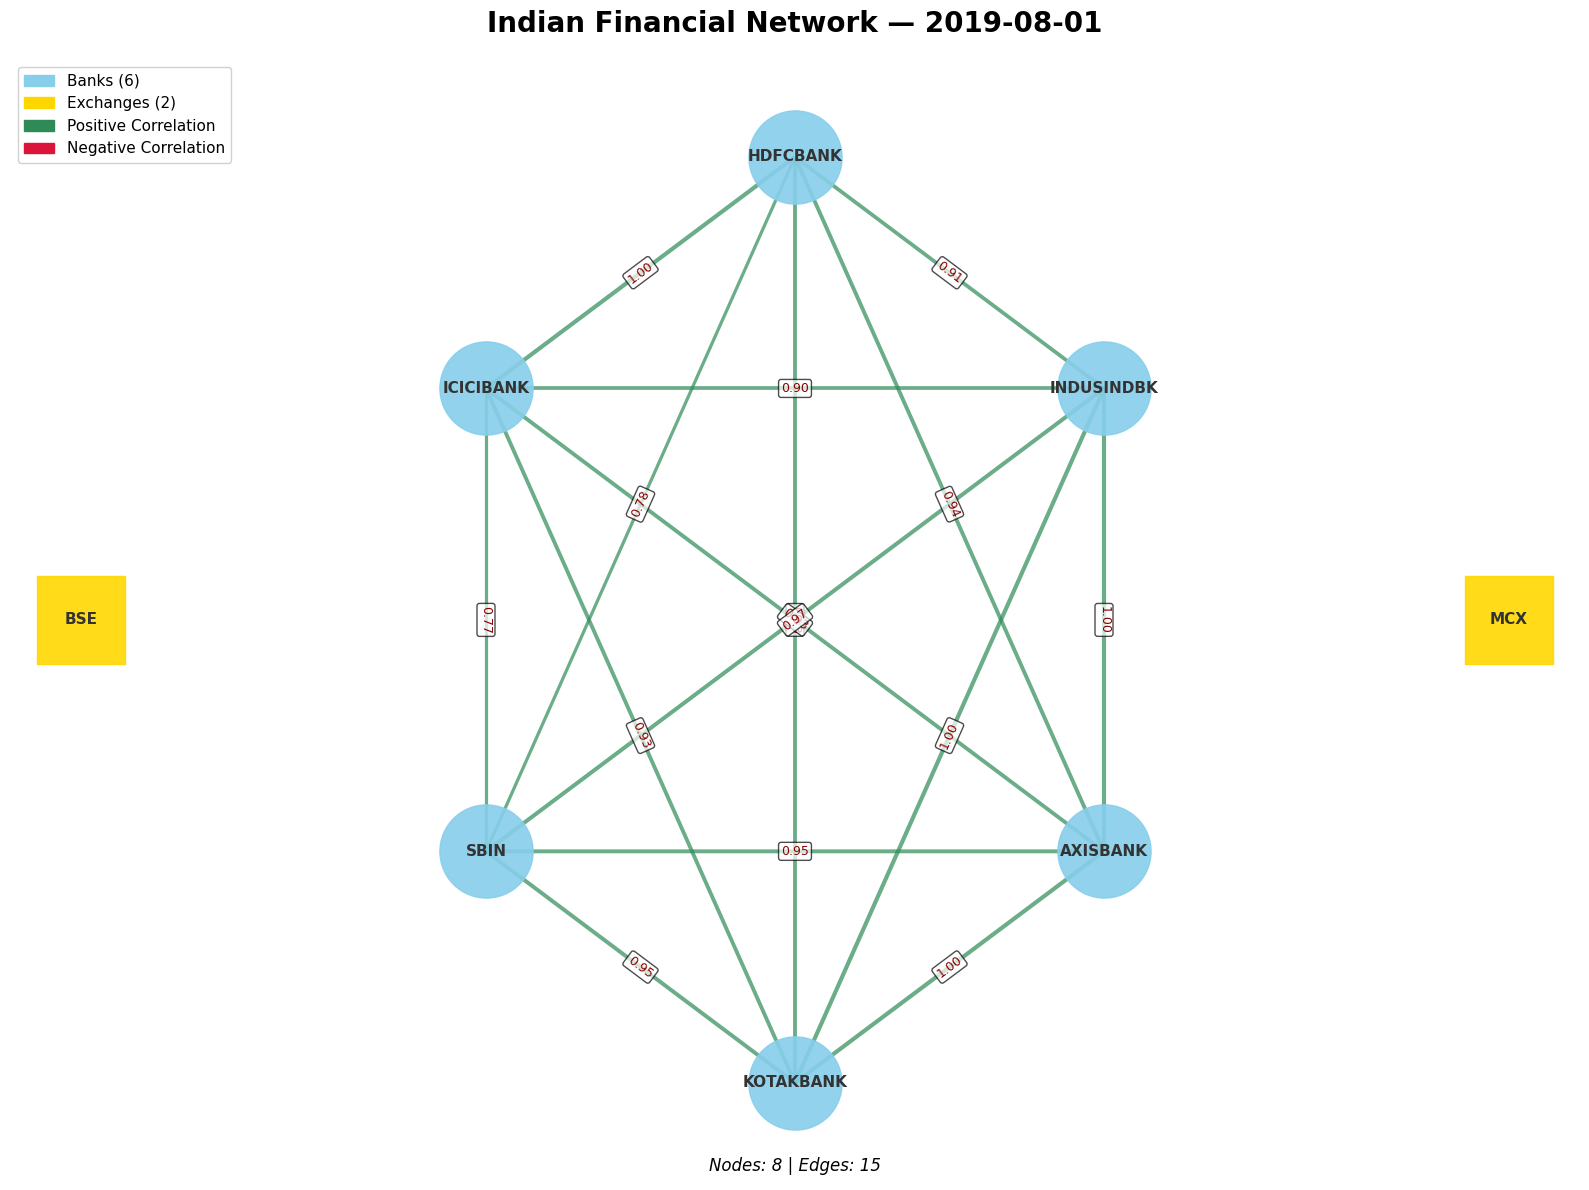

In [8]:
# Cell 5: Visualize the Final Graph (Enhanced)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

print("\n--- Visualizing the Network ---")

if financial_graph and financial_graph.number_of_nodes() > 0:
    plt.figure(figsize=(16, 12), facecolor='white')
    
    # --- Separate nodes by type ---
    bank_nodes = [n for n, d in financial_graph.nodes(data=True) if d.get('type') == 'bank']
    exchange_nodes = [n for n, d in financial_graph.nodes(data=True) if d.get('type') == 'exchange']
    
    # --- Use circular layout for banks, place exchanges on the outside ---
    # Create a shell layout: inner ring = banks (connected), outer ring = exchanges (isolated)
    if bank_nodes and exchange_nodes:
        pos = nx.shell_layout(financial_graph, nlist=[bank_nodes, exchange_nodes])
    else:
        pos = nx.spring_layout(financial_graph, k=2.0, iterations=100, seed=42)
    
    # --- Draw exchanges (outer nodes) ---
    nx.draw_networkx_nodes(financial_graph, pos, 
                           nodelist=exchange_nodes,
                           node_color='#FFD700',  # Gold
                           node_size=4000,
                           node_shape='s',  # Square
                           alpha=0.9)
    
    # --- Draw banks (inner nodes) ---
    nx.draw_networkx_nodes(financial_graph, pos, 
                           nodelist=bank_nodes,
                           node_color='#87CEEB',  # Sky blue
                           node_size=4500,
                           node_shape='o',  # Circle
                           alpha=0.9)
    
    # --- Draw edges with varying thickness based on correlation strength ---
    edges = financial_graph.edges(data=True)
    if edges:
        edge_weights = [abs(d.get('weight', 0.5)) * 3 for u, v, d in edges]
        edge_colors = ['#2E8B57' if d.get('weight', 0) > 0 else '#DC143C' for u, v, d in edges]
        
        nx.draw_networkx_edges(financial_graph, pos, 
                               width=edge_weights,
                               alpha=0.7,
                               edge_color=edge_colors,
                               style='solid')
    
    # --- Draw labels with cleaner names ---
    labels = {node: node.replace('.NS', '') for node in financial_graph.nodes()}
    nx.draw_networkx_labels(financial_graph, pos, labels,
                            font_size=11, 
                            font_weight='bold',
                            font_color='#333333')
    
    # --- Draw edge weights ---
    edge_labels = nx.get_edge_attributes(financial_graph, 'weight')
    edge_labels_rounded = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(financial_graph, pos, 
                                  edge_labels=edge_labels_rounded,
                                  font_size=9,
                                  font_color='#8B0000',
                                  bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    # --- Title and legend ---
    plt.title(f"Indian Financial Network — {target_date.date()}", 
              fontsize=20, fontweight='bold', pad=20)
    
    # Create legend
    bank_patch = mpatches.Patch(color='#87CEEB', label=f'Banks ({len(bank_nodes)})')
    exchange_patch = mpatches.Patch(color='#FFD700', label=f'Exchanges ({len(exchange_nodes)})')
    pos_edge = mpatches.Patch(color='#2E8B57', label='Positive Correlation')
    neg_edge = mpatches.Patch(color='#DC143C', label='Negative Correlation')
    
    plt.legend(handles=[bank_patch, exchange_patch, pos_edge, neg_edge], 
               loc='upper left', fontsize=11, framealpha=0.9)
    
    # --- Stats annotation ---
    stats_text = f"Nodes: {financial_graph.number_of_nodes()} | Edges: {financial_graph.number_of_edges()}"
    plt.figtext(0.5, 0.02, stats_text, ha='center', fontsize=12, style='italic')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
else:
    print("Cannot visualize an empty graph.")